Loaded config:
  output_dir: /Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_py/Diff_Evolution_red_n/log/rhos_c_ov_kex
  log_file:   /Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_py/Diff_Evolution_red_n/log/rhos_c_ov_kex/calibration_log.csv

Calibrated parameters: ['rho.max', 'rho.null', 'c.ov', 'k.exp']
Fixed parameters: {'k.ov': 0.38, 'eta.null': '8.5e6', 'tau': 1.2e-05}

Parameter normalization complete.


/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_2700/37956635.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig3.tight_layout()


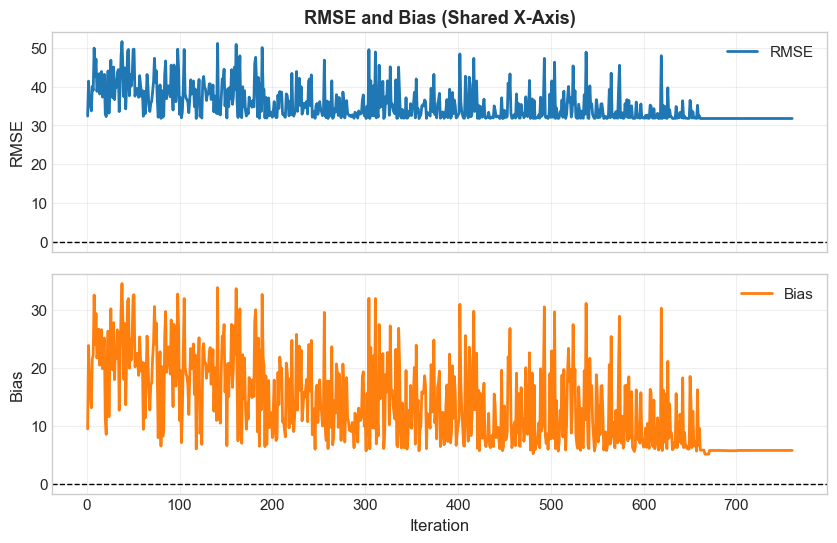

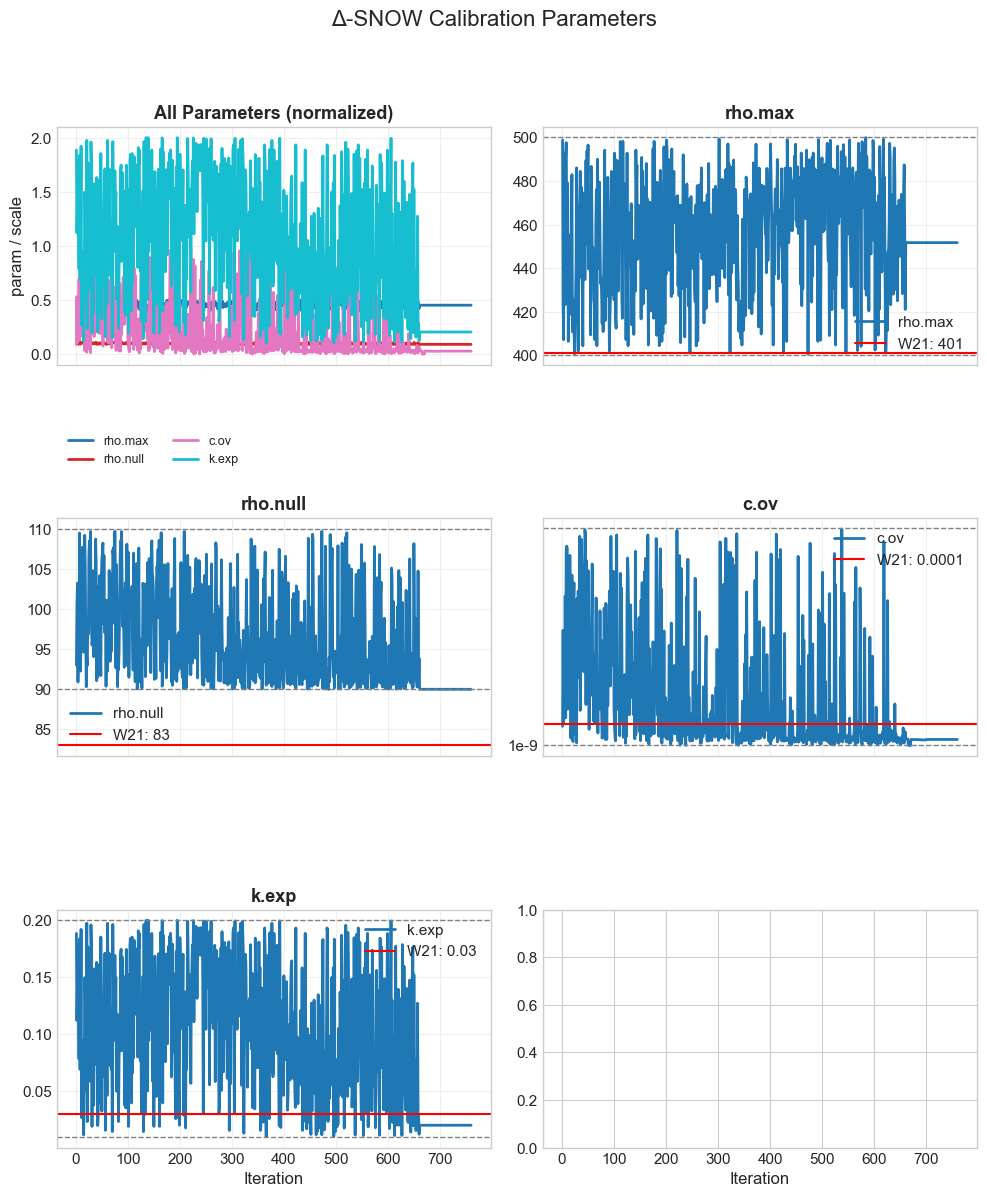

In [5]:
# ============================================================
# Δ-SNOW Calibration Plotting Script (Notebook Version)
# ------------------------------------------------------------
# Automatically:
#  - Loads YAML config
#  - Loads calibration log from output_dir
#  - Reads calibrated parameters, bounds, scale factors
#  - Converts parameter columns to numeric safely
#  - Normalizes parameters
#  - Plots RMSE/Bias and parameter evolution
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yaml
from pathlib import Path

# ============================================================
# USER: specify config file path here
# ============================================================
config_path = ("/Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_py/Diff_Evolution_red_n/log/rhos_c_ov_kex/config_calib.yml")

# ============================================================
# LOAD YAML CONFIG
# ============================================================
with open(config_path, "r") as f:
    cfg = yaml.safe_load(f)

paths = cfg["paths"]
param_cfg = cfg["parameters"]

output_dir = Path(paths["output_dir"])

log_path = output_dir / "calibration_log.csv"
# load manualy specified log file



print("Loaded config:")
print("  output_dir:", output_dir)
print("  log_file:  ", log_path)

# ============================================================
# LOAD PARAMETER METADATA
# ============================================================
param_names = param_cfg["names"]          # List[str] — calibrated parameters
bounds_unscaled = param_cfg["bounds"]     # List[[lo, hi], ...]
scale_factors = param_cfg["scale"]        # List[float]
fixed_params = param_cfg.get("fixed", {}) # Dict[str, float]

print("\nCalibrated parameters:", param_names)
print("Fixed parameters:", fixed_params)

# ============================================================
# LOAD CALIBRATION LOG
# ============================================================
metrics = pd.read_csv(log_path)

csv_params = list(metrics.columns[3:])  # rmse, bias, then parameters

if csv_params != param_names:
    raise ValueError(
        f"\nParameter mismatch:\n"
        f"  YAML: {param_names}\n"
        f"  CSV:  {csv_params}\n"
        "→ Did you use the correct config for this calibration run?\n"
    )

iters = metrics["iteration"]

# ============================================================
# SAFE NUMERIC NORMALIZATION
# ============================================================
norm_params = pd.DataFrame()

for p, s in zip(param_names, scale_factors):
    # force numeric conversion
    col = pd.to_numeric(metrics[p], errors="coerce")
    norm_params[p] = col / float(s)

print("\nParameter normalization complete.")

# ============================================================
# STYLE
# ============================================================
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "figure.titlesize": 16,
        "lines.linewidth": 2,
    }
)

# ============================================================
# FIGURE 1 — Separate RMSE (top) and Bias (bottom)
#             Shared X-axis, aligned panels
# ============================================================

fig3, (ax_rmse, ax_bias) = plt.subplots(
    2, 1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.1}
)

# -------------------------
# TOP: RMSE
# -------------------------
ax_rmse.plot(iters, metrics["rmse"], color="tab:blue", label="RMSE")
ax_rmse.set_ylabel("RMSE")
ax_rmse.set_title("RMSE and Bias (Shared X-Axis)")
ax_rmse.grid(alpha=0.3)
ax_rmse.legend()

# optional reference lines
ax_rmse.axhline(0, color="black", linestyle="--", linewidth=1)

# -------------------------
# BOTTOM: BIAS
# -------------------------

ax_bias.plot(
    iters,
    metrics["bias"],
    color="tab:orange",
    label=f"Bias"
)

ax_bias.set_ylabel("Bias")
ax_bias.set_xlabel("Iteration")
ax_bias.grid(alpha=0.3)
ax_bias.legend()

# Optional bias = 0 line
ax_bias.axhline(0, color="black", linestyle="--", linewidth=1)

fig3.tight_layout()
plt.show()
# ============================================================
# FIGURE 2 — PARAMETER EVOLUTION
# ============================================================

n_params = len(param_names)
n_rows = int(np.ceil((n_params + 1) / 2))  # +1 for normalized overview
n_cols = 2

fig2, axes = plt.subplots(
    n_rows, n_cols, figsize=(10, 4 * n_rows), sharex=True
)
axes = np.array(axes).reshape(n_rows, n_cols)

# -------------------------------
# Panel (0,0): All normalized parameters
# -------------------------------
ax_all = axes[0, 0]
colors = plt.cm.tab10(np.linspace(0, 1, n_params))

for p, c in zip(param_names, colors):
    ax_all.plot(iters, norm_params[p], label=p, color=c)

ax_all.set_title("All Parameters (normalized)")
ax_all.set_ylabel("param / scale")
ax_all.grid(alpha=0.3)
ax_all.legend(fontsize=9, ncol=2, bbox_to_anchor=(0.0, -0.25), loc="upper left")

# -------------------------------
# Panel grid for individual parameters
# -------------------------------
axes_flat = axes.flatten()
plot_index = 1

# Optional Winkler reference parameters
winkler_ref = {
    "rho.max": 401,
    "rho.null": 83,
    "c.ov": 1e-4,
    "k.ov": 1.0,
    "k.exp": 0.030,
    "tau": 0.03,
    "eta.null": 8.5e6,
}

for p, (lo, hi) in zip(param_names, bounds_unscaled):

    ax = axes_flat[plot_index]

    # evolution of unscaled param
    ax.plot(iters, metrics[p], label=p)

    # bounds
    ax.axhline(lo, color="gray", linestyle="--", linewidth=1)
    ax.axhline(hi, color="gray", linestyle="--", linewidth=1)

    # Winkler reference if available
    if p in winkler_ref:
        ax.axhline(
            winkler_ref[p],
            color="red",
            linestyle="-",
            linewidth=1.5,
            label=f"W21: {winkler_ref[p]}",
        )

    ax.set_title(p)
    ax.grid(alpha=0.3)
    ax.legend()

    plot_index += 1

# Label bottom row
for ax in axes[-1]:
    ax.set_xlabel("Iteration")

fig2.suptitle("Δ-SNOW Calibration Parameters", y=0.995)
fig2.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

In [15]:
from multiprocessing import Pool, cpu_count, set_start_method
from pathlib import Path

In [16]:
cpu_count()


12